<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/ML_TASK_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Study of Classification Evaluation Metrics


In [ ]:
import numpy as np #importing the required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

##Load and Preprocess Dataset

In [ ]:
df = pd.read_csv("/content/Titanic-Dataset-kaggle.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#droping the irrelevent columns

df_clean = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform( #imputing with median
    lambda x: x.fillna(x.median())
)

df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0], inplace=True) #imputing with mode

/tmp/ipykernel_1762/4101272289.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0], inplace=True) #imputing with mode


In [ ]:
print(df_clean.isnull().sum()) #cleaned dataframe

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


In [ ]:
# Label encode Sex
le_sex = LabelEncoder()
df_clean["Sex"] = le_sex.fit_transform(df_clean["Sex"])

In [ ]:
# One-Hot Encode Embarked
df_clean = pd.get_dummies(df_clean, columns=["Embarked"], drop_first=True)

In [ ]:
# Separate Features (X) and Target (y)
X = df_clean.drop(columns=["Survived"])
y = df_clean["Survived"]

In [ ]:
#splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [ ]:
# Train SVM Model
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Train Initial KNN Model (e.g., K=5)
knn_initial = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn_initial.fit(X_train_scaled, y_train)

KNeighborsClassifier()

##Elbow Method for KNN

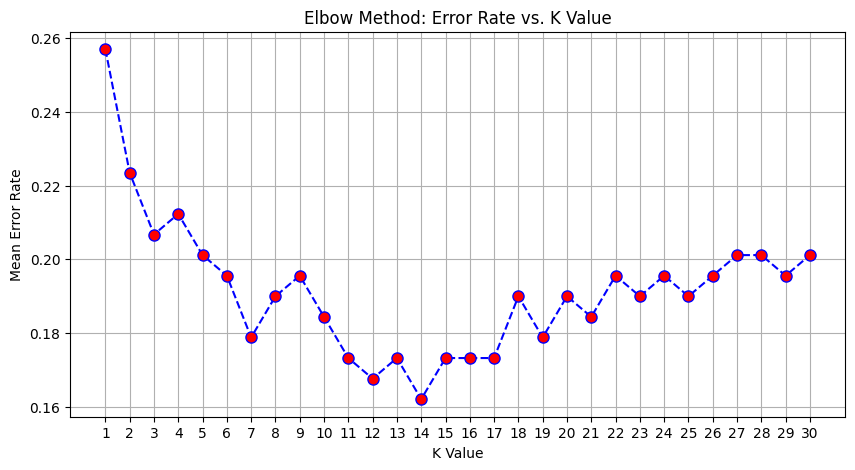

Optimal K determined by Elbow Method: 14
=== Evaluation: SVM (RBF) ===
Confusion Matrix:
[[102   8]
 [ 26  43]]
Accuracy : 0.8101
Precision: 0.8431
Recall   : 0.6232
F1-Score : 0.7167

=== Evaluation: KNN (Optimal K=14) ===
Confusion Matrix:
[[103   7]
 [ 22  47]]
Accuracy : 0.8380
Precision: 0.8704
Recall   : 0.6812
F1-Score : 0.7642



In [ ]:
error_rate = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

# Plot Elbow Method Graph
plt.figure(figsize=(10, 5))
plt.plot(
    k_range,
    error_rate,
    color="blue",
    linestyle="dashed",
    marker="o",
    markerfacecolor="red",
    markersize=8,
)
plt.title("Elbow Method: Error Rate vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Error Rate")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Find optimal K automatically
optimal_k = k_range[np.argmin(error_rate)]
print(f"Optimal K determined by Elbow Method: {optimal_k}")

# Retrain KNN with Optimal K
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)


def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"=== Evaluation: {model_name} ===")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
    }


# Evaluate SVM and Optimal KNN
svm_metrics = evaluate_model(svm_model, X_test_scaled, y_test, "SVM (RBF)")
knn_metrics = evaluate_model(
    knn_optimal, X_test_scaled, y_test, f"KNN (Optimal K={optimal_k})"
)